In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import time
import random
import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Check if torch will use Apple Silicon GPU

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

In [ ]:
movielens_data_dir = "ml-32m"

In [ ]:
num_ratings_to_read = 35_000_000

df_ratings = pd.read_csv(movielens_data_dir + '/ratings.csv', nrows=num_ratings_to_read)

In [ ]:
len(df_ratings)

In [ ]:
# clean the ratings data
df_ratings = df_ratings.dropna()
df_ratings['movieId'] = df_ratings['movieId'].astype(int, copy=False)

In [ ]:
df_ratings.head(5)

In [ ]:
df_movies = pd.read_csv(movielens_data_dir + '/movies.csv')

In [ ]:
df_movies.head(3)

In [ ]:
df_tags = pd.read_csv(movielens_data_dir + '/tags.csv')

In [ ]:
df_tags['tag'] = df_tags['tag'].str.lower()
df_tags['tag'] = df_tags['tag'].str.strip()

In [ ]:
df_tags.head(3)

In [ ]:
counts = df_tags.groupby('tag').size().reset_index(name='count')
df_tags_sorted_counts = counts.sort_values(by='count', ascending=False)

MIN_NUM_TAGS = 1000
df_tags_final_counts = df_tags_sorted_counts[df_tags_sorted_counts['count'] > MIN_NUM_TAGS]  
df_tags_final_counts.head(3)

In [ ]:
# Get the final tags we want to use as movie features
final_movie_tags = set(df_tags_final_counts['tag'].tolist())
len(final_movie_tags)

# Movie Feature Processing

In [ ]:
# let's only work with movies with enough ratings.

min_ratings_per_movie = 1_500

# get the number of ratings per movie
df_movies_to_num_ratings = df_ratings.groupby('movieId', as_index=False)['rating'].count()
print("total movies in corpus: ", len(df_movies_to_num_ratings))

df_movies_to_num_ratings = df_movies_to_num_ratings.sort_values(by=['rating'], ascending=False)
df_movies_to_num_ratings = df_movies_to_num_ratings[df_movies_to_num_ratings['rating'] > min_ratings_per_movie]
print("movies with enough ratings: ", len(df_movies_to_num_ratings))

# get list of the top movies by number of ratings.
top_movies = df_movies_to_num_ratings.movieId.tolist()

In [ ]:
# keep a map of movieId to number of ratings.
movieId_to_num_ratings = {}
movieId_list = df_movies_to_num_ratings.movieId.tolist()
rating_list = df_movies_to_num_ratings.rating.tolist()
for i in range(len(movieId_list)):
  movieId_to_num_ratings[movieId_list[i]] = rating_list[i]

In [ ]:
# map movieId to title
movieId_to_title = {}
title_to_movieId = {}

# map moveiId to year
movieId_to_year = {}

movieId_list = df_movies.movieId.tolist()
title_list = df_movies.title.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  title = title_list[i]

  movieId_to_title[movieId] = title
  title_to_movieId[title] = movieId

  match = re.search(r"\(\d+\)\s*$", title)
  if match:
    year = title[match.start()+1:match.end()-1]
    movieId_to_year[movieId] = year
  else:
    movieId_to_year[movieId] = -1

In [ ]:
# keep track of the number of unique year values we see in movieId_to_year
year_to_num_movies = {}
for movieId,year in movieId_to_year.items():
  if year not in year_to_num_movies:
    year_to_num_movies[year] = 0
  year_to_num_movies[year] += 1

In [ ]:
# print the top movies
for movieId in top_movies[0:10]:
  print(movieId, movieId_to_title[movieId], movieId_to_num_ratings[movieId])

In [ ]:
# map movieId to list of genres for that movie
genres = set()
movieId_to_genres = {}

movieId_list = df_movies.movieId.tolist()
genre_list = df_movies.genres.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  if movieId not in top_movies:
    continue

  movieId_to_genres[movieId] = set()

  for genre in genre_list[i].split('|'):
    genres.add(genre)
    movieId_to_genres[movieId].add(genre)

In [ ]:
movieId_to_genres[title_to_movieId['Matrix, The (1999)']]

In [ ]:
# map movieId to the counts of tags for that movie
movieId_to_tag_to_count = {}

movieId_list = df_tags.movieId.tolist()
tag_list = df_tags.tag.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  if movieId not in top_movies:
    continue
      
  if movieId not in movieId_to_tag_to_count:
    movieId_to_tag_to_count[movieId] = {}

  tag = tag_list[i]
  if tag not in final_movie_tags:
    continue
  if tag not in movieId_to_tag_to_count[movieId]:
    movieId_to_tag_to_count[movieId][tag] = 0

  movieId_to_tag_to_count[movieId][tag] += 1

In [ ]:
# movieId_to_tag_to_count[title_to_movieId['Matrix, The (1999)']]

In [ ]:
# for every movie, get the avg rating
df_movies_to_avg_rating = df_ratings.groupby('movieId', as_index=False)['rating'].mean()

movieId_to_avg_rating = {}

movieId_list = df_movies_to_avg_rating.movieId.tolist()
rating_list = df_movies_to_avg_rating.rating.tolist()
for i in range(len(movieId_list)):
  if movieId_list[i] not in top_movies: continue
  movieId_to_avg_rating[movieId_list[i]] = rating_list[i]

In [ ]:
# build ITEM movieId embedding mapping
item_emb_movieId_to_i = {s:i for i,s in enumerate(top_movies)}
item_emb_i_to_movieId = {i:s for s,i in item_emb_movieId_to_i.items()}

In [ ]:
# build ITEM genre feature context
genre_to_i = {s:i for i,s in enumerate(genres)}
i_to_genre = {i:s for s,i in genre_to_i.items()}

In [ ]:
# build ITEM year embedding mapping
year_to_i = {s:i for i,s in enumerate(year_to_num_movies.keys())}
i_to_year = {i:s for s,i in year_to_i.items()}

In [ ]:
# build ITEM tag feature context
tag_to_i = {s:i for i,s in enumerate(final_movie_tags)}
i_to_tag = {i:s for s,i in tag_to_i.items()}

# User Feature Processing

In [ ]:
# user_context_movies is no longer needed.
# The user's watch history is now represented as avg pooling over shared item embeddings.
# This saves substantial memory as we no longer need a multi-hot vector per training example.


In [ ]:
df_ratings_final = df_ratings[df_ratings.movieId.isin(top_movies)]
df_ratings_final = df_ratings_final.sort_values(['userId', 'timestamp'], ascending=[True, True])

In [ ]:
df_ratings_final.head(3)

In [ ]:
# aggregate dataframe down into one row per user and list of their movies and ratings.
df_ratings_final = df_ratings_final.groupby('userId').agg(
    {'movieId': lambda x: list(x),
     'rating': lambda y: list(y),
     'timestamp': lambda z: list(z)
    }).reset_index()

In [ ]:
df_ratings_final.head(3)

In [ ]:
# The user context contains two halves:
#   First half  (indices 0 .. len(genres)-1)          : per-genre avg rating (debiased)
#   Second half (indices len(genres) .. 2*len(genres)-1): per-genre watch count fraction
# The watch history (movie IDs) is stored separately and handled via avg pooling in the model.
user_context_size = len(genres) * 2

user_context_genre_avg_rating_to_i  = {s: i             for i, s in enumerate(list(genres))}
user_context_i_to_genre_avg_rating  = {i: s             for s, i in user_context_genre_avg_rating_to_i.items()}

user_context_genre_watch_count_to_i = {s: len(genres) + i for i, s in enumerate(list(genres))}
user_context_i_to_genre_watch_count = {i: s             for s, i in user_context_genre_watch_count_to_i.items()}


# Generate Training Examples

In [ ]:
# simulate training examples by masking out some of the user's watched movies from their context, and using them as labels.
# we do not want the 'movie to predict' in their watch history, as we are trying to simulate the following:
# given the user's watch history, what would they rate this new movie?
# NOTE: this is not the same as a train/test split. This is just simulating how training examples would look like on a movie platform.

percent_ratings_as_watch_history = 0.9

min_ratings_per_user = 20 # ignore users with too few movie watches
max_ratings_per_user = 500 # ignore users with way too many movie watches
too_few_ratings = 0
too_many_ratings = 0

user_to_movie_to_rating_WATCH_HISTORY = {}
user_to_movie_to_rating_LABEL = {}
user_to_movie_to_timestamp_LABEL = {}

# loop over each column as this is much, much faster than going row by row.
user_list = df_ratings_final['userId'].tolist()
movieId_list_list = df_ratings_final['movieId'].tolist()
rating_list_list = df_ratings_final['rating'].tolist()
timestamp_list_list = df_ratings_final['timestamp'].tolist()

for i in range(len(user_list)):
  userId = user_list[i]
  movieId_list = movieId_list_list[i]
  rating_list = rating_list_list[i]
  timestamp_list = timestamp_list_list[i]

  num_rated_movies = len(movieId_list)

  # ignore users with too few or too many ratings.
  if num_rated_movies < min_ratings_per_user:
    too_few_ratings += 1
    continue
  if num_rated_movies > max_ratings_per_user:
    too_many_ratings += 1
    continue

  # set up training example maps.
  user_to_movie_to_rating_WATCH_HISTORY[userId] = {}
  user_to_movie_to_rating_LABEL[userId] = {}
  user_to_movie_to_timestamp_LABEL[userId] = {}

  # put earlier watched movies into user's watch history (features) and leave later watched movies as labels to predict.
  rated_movies = list(zip(movieId_list, rating_list, timestamp_list))
  for movieId,rating,timestamp in rated_movies[:int(num_rated_movies * percent_ratings_as_watch_history)]:
    user_to_movie_to_rating_WATCH_HISTORY[userId][movieId] = rating
  for movieId,rating,timestamp in rated_movies[int(num_rated_movies * percent_ratings_as_watch_history):]:
    user_to_movie_to_rating_LABEL[userId][movieId] = rating
    user_to_movie_to_timestamp_LABEL[userId][movieId] = timestamp

In [ ]:
len(user_list), len(user_to_movie_to_rating_WATCH_HISTORY.keys()), too_few_ratings, too_many_ratings

In [ ]:
# for every user, get their avg rating.
# this will help us debias each user's rating.
user_to_avg_rating = {}

# NOTE: only use ratings from their synthetic watch history.
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
  user_to_avg_rating[user] = 0
  for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys():
    user_to_avg_rating[user] += user_to_movie_to_rating_WATCH_HISTORY[user][movieId]

  user_to_avg_rating[user] /= len(user_to_movie_to_rating_WATCH_HISTORY[user].keys())

In [ ]:
user_to_avg_rating[1]

In [ ]:
# for every user, get the avg rating for every genre
user_to_genre_to_stat = {}

# NOTE: only use ratings from their synthetic watch history.
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
  user_to_genre_to_stat[user] = {}
  for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys():
    for genre in movieId_to_genres[movieId]:
      if genre not in user_to_genre_to_stat[user]:
        user_to_genre_to_stat[user][genre] = {
            'NUM_RATINGS': 0,
            'SUM_RATINGS': 0,
        }

      user_to_genre_to_stat[user][genre]['NUM_RATINGS'] += 1
      user_to_genre_to_stat[user][genre]['SUM_RATINGS'] += user_to_movie_to_rating_WATCH_HISTORY[user][movieId]

for user in user_to_genre_to_stat.keys():
  for genre in user_to_genre_to_stat[user].keys():
    num_ratings = user_to_genre_to_stat[user][genre]['NUM_RATINGS']
    sum_ratings = user_to_genre_to_stat[user][genre]['SUM_RATINGS']
    user_to_genre_to_stat[user][genre]['AVG_RATING'] = sum_ratings / num_ratings


In [ ]:
# Build per-user genre context and watch history.
#
# user_to_context:       [avg_rating_per_genre | watch_count_fraction_per_genre] — shape (2*len(genres),) per user
# user_to_watch_history: list of emb_idx for the most recent N watched movies

MAX_HISTORY_LEN = 50  # cap to most recent N movies; older watches add little signal via avg pool

user_to_context = {}
user_to_watch_history = {}

for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
    context = [0.0] * user_context_size
    total_watches = len(user_to_movie_to_rating_WATCH_HISTORY[user])

    for genre in user_to_genre_to_stat[user].keys():
        # First half: debiased avg rating per genre
        context[user_context_genre_avg_rating_to_i[genre]] = float(
            user_to_genre_to_stat[user][genre]['AVG_RATING'] - user_to_avg_rating[user]
        )
        # Second half: fraction of total watches in this genre
        context[user_context_genre_watch_count_to_i[genre]] = float(
            user_to_genre_to_stat[user][genre]['NUM_RATINGS'] / total_watches
        )
    user_to_context[user] = context

    # Watch history: embedding indices only, capped to most recent N
    watch_ids = [
        item_emb_movieId_to_i[movieId]
        for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys()
        if movieId in item_emb_movieId_to_i
    ]
    user_to_watch_history[user] = watch_ids[-MAX_HISTORY_LEN:]


In [ ]:
# for every movie, create a training example feature GENRE context vector lookup
# it will contain the movie's genres.
movieId_to_genre_context = {}
for movieId in top_movies:
  genre_context = [0.0] * len(genres)

  for genre in movieId_to_genres[movieId]:
    genre_context[genre_to_i[genre]] = float(1.0)

  movieId_to_genre_context[movieId] = genre_context

In [ ]:
# for every movie, create a training example feature TAG context vector lookup.
# Tag values are normalized: each value is that tag's count divided by the sum of all tag counts
# for that movie, making the vector a probability distribution over tags.
# Movies with zero total tag count get an all-zero vector.
movieId_to_tag_context = {}
for movieId in top_movies:
    tag_context = [0.0] * len(final_movie_tags)

    total_count = sum(count for tag, count in movieId_to_tag_to_count[movieId].items())
    if total_count > 0:
        for tag, count in movieId_to_tag_to_count[movieId].items():
            tag_context[tag_to_i[tag]] = float(count) / total_count

    movieId_to_tag_context[movieId] = tag_context

In [ ]:
# Build per-user tag profile: unweighted average of normalized tag vectors across watch history.
# Mirrors the avg-pool approach used for movie embeddings in the user history tower.

tag_matrix = np.array([movieId_to_tag_context[movieId] for movieId in top_movies], dtype=np.float32)
movieId_to_row = {movieId: i for i, movieId in enumerate(top_movies)}

user_to_tag_context = {}
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
    rows = [
        movieId_to_row[movieId]
        for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys()
        if movieId in movieId_to_row
    ]
    if rows:
        user_to_tag_context[user] = tag_matrix[rows].mean(axis=0).tolist()
    else:
        user_to_tag_context[user] = [0.0] * len(final_movie_tags)

# Build Datasets

In [ ]:
# Prepare the buckets for our timestamps so we can use them as categorical features
timestamp_num_bins = 1500
timestamp_bins = torch.tensor(np.linspace(df_ratings['timestamp'].min(), df_ratings['timestamp'].max(), timestamp_num_bins))

In [ ]:
# PAD_IDX is one beyond the last valid movie index (0..top_movies_len-1).
# The Embedding layer's padding_idx=PAD_IDX will zero-out those positions automatically.
PAD_IDX = len(top_movies)

def pad_history_batch(histories):
    """Pad variable-length watch histories to the batch max length.
    Returns a (batch, max_hist_len) long tensor. Padded positions are PAD_IDX.
    """
    max_len = max((len(h) for h in histories), default=1)
    padded = torch.full((len(histories), max_len), PAD_IDX, dtype=torch.long)
    for i, hist in enumerate(histories):
        if len(hist) > 0:
            padded[i, :len(hist)] = torch.tensor(hist, dtype=torch.long)
    return padded

def build_dataset(users):
    X = []
    X_history = []   # list of emb_idx lists (variable length per user)
    X_tag = []       # user tag profile: avg of watched movies' tag vectors
    timestamp = []
    target_movieId = []
    target_movieId_genre_context = []
    target_movieId_tag_context = []
    target_movieId_year = []
    Y = []

    for user in users:
        for movieId in user_to_movie_to_rating_LABEL[user].keys():
            X.append(user_to_context[user])
            X_history.append(user_to_watch_history[user])
            X_tag.append(user_to_tag_context[user])
            timestamp.append(user_to_movie_to_timestamp_LABEL[user][movieId])
            target_movieId.append(item_emb_movieId_to_i[movieId])
            target_movieId_genre_context.append(movieId_to_genre_context[movieId])
            target_movieId_tag_context.append(movieId_to_tag_context[movieId])
            target_movieId_year.append(year_to_i[movieId_to_year[movieId]])
            Y.append(float(user_to_movie_to_rating_LABEL[user][movieId] - user_to_avg_rating[user]))

    X = torch.tensor(X)
    X_tag = torch.tensor(X_tag)
    Y = torch.tensor(Y)
    target_movieId = torch.tensor(target_movieId)
    target_movieId_genre_context = torch.tensor(target_movieId_genre_context)
    target_movieId_tag_context = torch.tensor(target_movieId_tag_context)
    target_movieId_year = torch.tensor(target_movieId_year)
    timestamp = torch.bucketize(torch.tensor(timestamp), timestamp_bins, right=False)

    return X, X_history, X_tag, timestamp, Y, target_movieId, target_movieId_genre_context, target_movieId_tag_context, target_movieId_year


In [ ]:
# user users with enough ratings to predict to be useful for model learning.
final_users = []

for user in user_to_movie_to_rating_LABEL.keys():
  num_ratings = len(user_to_movie_to_rating_LABEL[user])

  # having at least 2 watched movies in the user's LABEL split means they have watched at least 20 movies
  # 18 of these movies are used for the user's watch history
  if num_ratings >= 2 and num_ratings < 500:
    final_users.append(user)

len(final_users)

In [ ]:
# split users into train and validation users
percent_users_train = 0.9

random.shuffle(final_users)

train_users = final_users[:int(len(final_users) * percent_users_train)]
validation_users = final_users[int(len(final_users) * percent_users_train):]

In [ ]:
X_train, X_history_train, X_tag_train, timestamp_train, Y_train, target_movieId_train, target_movieId_genre_context_train, target_movieId_tag_context_train, target_movieId_year_train = build_dataset(train_users)
X_val,   X_history_val,   X_tag_val,   timestamp_val,   Y_val,   target_movieId_val,   target_movieId_genre_context_val,   target_movieId_tag_context_val,   target_movieId_year_val   = build_dataset(validation_users)


In [ ]:
print("train:")
print("  X_train (genre context):               ", X_train.shape)
print("  X_history_train (list of lists):        ", f"{len(X_history_train)} examples, variable-length histories")
print("  X_tag_train (user tag profile):         ", X_tag_train.shape)
print("  timestamp_train:                        ", timestamp_train.shape)
print("  Y_train:                                ", Y_train.shape)
print("  target_movieId_train:                   ", target_movieId_train.shape)
print("  target_movieId_genre_context_train:     ", target_movieId_genre_context_train.shape)
print("  target_movieId_tag_context_train:       ", target_movieId_tag_context_train.shape)
print("  target_movieId_year_train:              ", target_movieId_year_train.shape)
print()
print("val:")
print("  X_val (genre context):                 ", X_val.shape)
print("  X_history_val (list of lists):          ", f"{len(X_history_val)} examples, variable-length histories")
print("  X_tag_val (user tag profile):           ", X_tag_val.shape)
hist_lens = [len(h) for h in X_history_train]
print(f"  history length stats — min: {min(hist_lens)}  max: {max(hist_lens)}  mean: {sum(hist_lens)/len(hist_lens):.1f}")


# Build our Two Tower Model

In [ ]:
'''
User side:
  avg_pool(item_emb[watched_movies])  --> history_emb (item_movieId_embedding_size)
                                              \
  [avg_rating | watch_count_frac]              \
  per genre --> user_genre_tower --> genre_emb  \
                                                 --> cat --> user_combined
  avg(tag_vecs[watched_movies])                /
  --> user_tag_tower --> tag_emb              /
                                             /
  timestamp_emb --> ts_tower --> ts_emb    /

Item side:
  movie_genres --> genre_tower \
  movie_tags   --> tag_tower    \
                                --> cat --> item_combined
  movie_id_emb --> item_tower  /
  movie_year   --> year_tower /

Prediction: dot_product(user_combined, item_combined)

Dimension constraint:
  user: item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size + user_tag_embedding_size
  item: item_genre_embedding_size + item_tag_embedding_size + item_movieId_embedding_size + item_year_embedding_size
  both must be equal.
  Default: 40 + 30 + 10 + 20 = 100 = 10 + 40 + 40 + 10 = 100
'''

class MovieRecommender(nn.Module):
    def __init__(self,
                 genres_len,
                 tags_len,
                 top_movies_len,
                 all_years_len,
                 timestamp_num_bins,
                 user_context_size,
                 item_genre_embedding_size=10,
                 item_tag_embedding_size=40,
                 item_movieId_embedding_size=40,
                 item_year_embedding_size=10,
                 user_genre_embedding_size=30,
                 user_tag_embedding_size=20,
                 timestamp_feature_embedding_size=10,
                ):
        """
        Args:
            genres_len (int): Number of unique genres.
            tags_len (int): Number of unique tags.
            top_movies_len (int): Number of movies in the embedding table.
            all_years_len (int): Number of unique release years.
            timestamp_num_bins (int): Number of timestamp buckets.
            user_context_size (int): Size of the user genre context vector (2*genres_len).
            item_genre_embedding_size (int): Output size of the item genre tower.
            item_tag_embedding_size (int): Output size of the item tag tower.
            item_movieId_embedding_size (int): Embedding dim for movie IDs.
                Shared between item tower and user history avg pooling.
            item_year_embedding_size (int): Output size of the year tower.
            user_genre_embedding_size (int): Output size of the user genre tower.
            user_tag_embedding_size (int): Output size of the user tag tower.
            timestamp_feature_embedding_size (int): Embedding dim for timestamps.
            Constraint: item_movieId_embedding_size + user_genre_embedding_size
                        + timestamp_feature_embedding_size + user_tag_embedding_size
                        == item_genre_embedding_size + item_tag_embedding_size
                           + item_movieId_embedding_size + item_year_embedding_size
        """
        super().__init__()

        # PAD index sits one beyond valid indices (0 .. top_movies_len-1)
        self.pad_idx = top_movies_len

        # ── Shared item embedding ─────────────────────────────────────────────
        # Used by BOTH the item tower (target movie) and the user history avg pool.
        self.item_embedding_lookup = nn.Embedding(
            top_movies_len + 1, item_movieId_embedding_size, padding_idx=top_movies_len
        )
        self.item_embedding_tower = nn.Sequential(
            nn.Linear(item_movieId_embedding_size, item_movieId_embedding_size),
            nn.Tanh()
        )

        # ── Item feature towers ───────────────────────────────────────────────
        self.item_genre_tower = nn.Sequential(
            nn.Linear(genres_len, item_genre_embedding_size),
            nn.Tanh()
        )
        self.item_tag_tower = nn.Sequential(
            nn.Linear(tags_len, item_tag_embedding_size),
            nn.Tanh()
        )
        self.year_embedding_lookup = nn.Embedding(all_years_len, item_year_embedding_size)
        self.year_embedding_tower = nn.Sequential(
            nn.Linear(item_year_embedding_size, item_year_embedding_size),
            nn.Tanh()
        )

        # ── User towers ───────────────────────────────────────────────────────
        self.user_genre_tower = nn.Sequential(
            nn.Linear(user_context_size, user_genre_embedding_size),
            nn.Tanh()
        )
        # Tag profile tower: takes avg of watched movies' tag vectors
        self.user_tag_tower = nn.Sequential(
            nn.Linear(tags_len, user_tag_embedding_size),
            nn.Tanh()
        )
        self.timestamp_embedding_lookup = nn.Embedding(timestamp_num_bins, timestamp_feature_embedding_size)
        self.timestamp_embedding_tower = nn.Sequential(
            nn.Linear(timestamp_feature_embedding_size, timestamp_feature_embedding_size),
            nn.Tanh()
        )

        # ── Dimension check ───────────────────────────────────────────────────
        user_side = item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size + user_tag_embedding_size
        item_side = item_genre_embedding_size + item_tag_embedding_size + item_movieId_embedding_size + item_year_embedding_size
        if user_side != item_side:
            raise ValueError(
                f"User embedding size ({user_side} = history {item_movieId_embedding_size} + "
                f"genre {user_genre_embedding_size} + timestamp {timestamp_feature_embedding_size} + "
                f"tag {user_tag_embedding_size}) "
                f"must match item embedding size ({item_side}). Adjust user_genre_embedding_size."
            )

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.01)
            if module.bias is not None:
                torch.nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.01)

    def forward(self, user_genre_contexts, user_tag_contexts, user_watch_history, timestamps,
                movie_genres, movie_tags, years, target_movieId):
        """
        Args:
            user_genre_contexts (Tensor): (batch, user_context_size) — per-genre avg rating + watch count fraction
            user_tag_contexts   (Tensor): (batch, tags_len)          — avg tag vector over watch history
            user_watch_history  (Tensor): (batch, max_hist_len)      — padded movie ID indices
            timestamps          (Tensor): (batch,)                   — bucketized timestamp indices
            movie_genres        (Tensor): (batch, genres_len)        — target movie genre features
            movie_tags          (Tensor): (batch, tags_len)          — target movie tag features
            years               (Tensor): (batch,)                   — target movie year indices
            target_movieId      (Tensor): (batch,)                   — target movie ID indices
        """
        # ── User history tower (unweighted avg pool over shared item embeddings) ─────
        history_embs = self.item_embedding_lookup(user_watch_history)
        mask = (user_watch_history != self.pad_idx).float().unsqueeze(-1)
        valid_count = mask.sum(dim=1).clamp(min=1)
        history_emb = (history_embs * mask).sum(dim=1) / valid_count         # (batch, item_movieId_embedding_size)

        # ── User genre tower ──────────────────────────────────────────────────
        genre_emb = self.user_genre_tower(user_genre_contexts)              # (batch, user_genre_embedding_size)

        # ── User tag tower ────────────────────────────────────────────────────
        tag_emb = self.user_tag_tower(user_tag_contexts)                    # (batch, user_tag_embedding_size)

        # ── Timestamp tower ───────────────────────────────────────────────────
        ts_emb = self.timestamp_embedding_tower(
            self.timestamp_embedding_lookup(timestamps)
        )                                                                    # (batch, timestamp_feature_embedding_size)

        # ── Combine user side ─────────────────────────────────────────────────
        user_combined = torch.cat([history_emb, genre_emb, tag_emb, ts_emb], dim=1)

        # ── Item tower ────────────────────────────────────────────────────────
        item_genre_emb = self.item_genre_tower(movie_genres)
        item_tag_emb   = self.item_tag_tower(movie_tags)
        item_emb       = self.item_embedding_tower(
            self.item_embedding_lookup(target_movieId)
        )
        year_emb       = self.year_embedding_tower(
            self.year_embedding_lookup(years)
        )

        item_combined = torch.cat([item_genre_emb, item_tag_emb, item_emb, year_emb], dim=1)

        # ── Dot product prediction ────────────────────────────────────────────
        preds = torch.einsum('ij, ij -> i', user_combined, item_combined)

        return preds


# Training Loop

In [86]:
# --- Training Loop ---

# Define model hyper-parameters
item_genre_embedding_size = 10
item_tag_embedding_size   = 40
item_movieId_embedding_size = 40
item_year_embedding_size  = 10

# Constraint:
#   item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size + user_tag_embedding_size
#   == item_genre_embedding_size + item_tag_embedding_size + item_movieId_embedding_size + item_year_embedding_size
#   40 + user_genre_embedding_size + 10 + user_tag_embedding_size == 10 + 40 + 40 + 10 == 100
#   => user_genre_embedding_size + user_tag_embedding_size = 50
#   => e.g. user_genre=30, user_tag=20
user_genre_embedding_size        = 30
user_tag_embedding_size          = 20
timestamp_feature_embedding_size = 10

# Instantiate the MovieRecommender model
model = MovieRecommender(
    genres_len=len(genres),
    tags_len=len(final_movie_tags),
    top_movies_len=len(top_movies),
    all_years_len=len(year_to_num_movies),
    timestamp_num_bins=timestamp_num_bins,
    user_context_size=user_context_size,
    item_genre_embedding_size=item_genre_embedding_size,
    item_tag_embedding_size=item_tag_embedding_size,
    item_movieId_embedding_size=item_movieId_embedding_size,
    item_year_embedding_size=item_year_embedding_size,
    user_genre_embedding_size=user_genre_embedding_size,
    user_tag_embedding_size=user_tag_embedding_size,
    timestamp_feature_embedding_size=timestamp_feature_embedding_size,
)

# Print the total number of trainable parameters in the model
print(f"Number of trainable parameters: {sum(p.nelement() for p in model.parameters() if p.requires_grad)}")


Number of trainable parameters: 180800


In [87]:
USE_GPU = False

if USE_GPU:
    mps_device = torch.device("mps")
    
    # Move the model to the GPU
    model.to(mps_device)
    
    # move validation data to MPS
    X_val = X_val.to(mps_device)
    timestamp_val = timestamp_val.to(mps_device)
    target_movieId_genre_context_val = target_movieId_genre_context_val.to(mps_device)
    target_movieId_tag_context_val = target_movieId_tag_context_val.to(mps_device)
    target_movieId_year_val = target_movieId_year_val.to(mps_device)
    target_movieId_val = target_movieId_val.to(mps_device)
    Y_val = Y_val.to(mps_device)
    
    # move training data to MPS
    X_train = X_train.to(mps_device)
    timestamp_train = timestamp_train.to(mps_device)
    target_movieId_genre_context_train = target_movieId_genre_context_train.to(mps_device)
    target_movieId_tag_context_train = target_movieId_tag_context_train.to(mps_device)
    target_movieId_year_train = target_movieId_year_train.to(mps_device)
    target_movieId_train = target_movieId_train.to(mps_device)
    Y_train = Y_train.to(mps_device)
else:
    # move validation data to CPU
    X_val = X_val.cpu()
    timestamp_val = timestamp_val.cpu()
    target_movieId_genre_context_val = target_movieId_genre_context_val.cpu()
    target_movieId_tag_context_val = target_movieId_tag_context_val.cpu()
    target_movieId_year_val = target_movieId_year_val.cpu()
    target_movieId_val = target_movieId_val.cpu()
    Y_val = Y_val.cpu()
    
    # move training data to CPU
    X_train = X_train.cpu()
    timestamp_train = timestamp_train.cpu()
    target_movieId_genre_context_train = target_movieId_genre_context_train.cpu()
    target_movieId_tag_context_train = target_movieId_tag_context_train.cpu()
    target_movieId_year_train = target_movieId_year_train.cpu()
    target_movieId_train = target_movieId_train.cpu()
    Y_train = Y_train.cpu()

In [88]:
# Set the loss function (Mean Squared Error Loss for regression)
loss_fn = torch.nn.MSELoss()

# Set the optimizer (Stochastic Gradient Descent)
# It will manage the updates to all parameters in `model.parameters()`
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

# Training configuration
minibatch_size = 64
loss_train = [] # To store training loss for each step
loss_val = []   # To store validation loss for full validation runs

log_every = 10_000      # How often to perform a full validation run and log
training_steps = 150_000 # Total training iterations

# Checkpointing
# - best_val checkpoint: saved whenever val loss improves; always reflects the best model seen so far
# - periodic checkpoint: saved every `checkpoint_every` steps regardless of val loss;
#   useful for going back to an earlier point if the best checkpoint turns out to be overfit
checkpoint_every = 30_000
checkpoint_dir   = 'saved_models'

In [89]:
import os

print("\nStarting training loop...")

# Tracks the lowest val loss seen so far; used to decide whether to save a new best checkpoint
best_val_loss = float('inf')

start = time.time()
for i in range(training_steps):
    is_full_val_run = False
    if i % log_every == 0:
        is_full_val_run = True

    if is_full_val_run:
        user_genre_contexts_batch = X_val
        user_tag_contexts_batch   = X_tag_val
        user_watch_history_batch  = pad_history_batch(X_history_val)
        timestamps_batch          = timestamp_val
        movie_genres_batch        = target_movieId_genre_context_val
        movie_tags_batch          = target_movieId_tag_context_val
        movie_years_batch         = target_movieId_year_val
        target_movieId_batch      = target_movieId_val
        Y_batch                   = Y_val

        model.eval()
        with torch.no_grad():
            preds = model(user_genre_contexts_batch, user_tag_contexts_batch, user_watch_history_batch, timestamps_batch,
                          movie_genres_batch, movie_tags_batch, movie_years_batch, target_movieId_batch)
            output = loss_fn(preds, Y_batch)

        loss_val.append(output.item())
    else:
        ix = torch.randint(0, X_train.shape[0], (minibatch_size,)).tolist()
        user_genre_contexts_batch = X_train[ix]
        user_tag_contexts_batch   = X_tag_train[ix]
        user_watch_history_batch  = pad_history_batch([X_history_train[j] for j in ix])
        timestamps_batch          = timestamp_train[ix]
        movie_genres_batch        = target_movieId_genre_context_train[ix]
        movie_tags_batch          = target_movieId_tag_context_train[ix]
        movie_years_batch         = target_movieId_year_train[ix]
        target_movieId_batch      = target_movieId_train[ix]
        Y_batch                   = Y_train[ix]

        model.train()
        preds = model(user_genre_contexts_batch, user_tag_contexts_batch, user_watch_history_batch, timestamps_batch,
                      movie_genres_batch, movie_tags_batch, movie_years_batch, target_movieId_batch)
        output = loss_fn(preds, Y_batch)

        optimizer.zero_grad()
        output.backward()
        optimizer.step()

        loss_train.append(output.item())

    if is_full_val_run:
        end = time.time()
        print("Total time: ", end - start, "seconds")
        start = time.time()

        if i >= log_every:
            avg_train_loss_last_batches = np.mean(loss_train[i-log_every:i])
        else:
            avg_train_loss_last_batches = output.item()
        val_loss = output.item()
        print(f"[TRAIN] i: {i:06d} | avg_loss (last {log_every} batches): {avg_train_loss_last_batches:.4f}")
        print(f"[VAL]   i: {i:06d} | loss: {val_loss:.4f}")

        # Save a checkpoint whenever val loss improves.
        # Overwrites the previous best so only one file is kept at a time.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_path = os.path.join(checkpoint_dir, 'best_checkpoint.pth')
            torch.save(model.state_dict(), best_path)
            print(f"  → New best val loss {best_val_loss:.4f}, saved {best_path}")

        # Save a periodic checkpoint every `checkpoint_every` steps.
        # Keeps one file per interval so you can load any past point for eval.
        if i > 0 and i % checkpoint_every == 0:
            periodic_path = os.path.join(checkpoint_dir, f'checkpoint_step_{i:06d}.pth')
            torch.save(model.state_dict(), periodic_path)
            print(f"  → Periodic checkpoint saved {periodic_path}")

        print()

print("Training complete.")
print(f"Best val loss: {best_val_loss:.4f} — weights saved to {os.path.join(checkpoint_dir, 'best_checkpoint.pth')}")



Starting training loop...
Total time:  1.5686419010162354 seconds
[TRAIN] i: 000000 | avg_loss (last 10000 batches): 0.9036
[VAL]   i: 000000 | loss: 0.9036
  → New best val loss 0.9036, saved saved_models/best_checkpoint.pth

Total time:  17.009023189544678 seconds
[TRAIN] i: 010000 | avg_loss (last 10000 batches): 0.8627
[VAL]   i: 010000 | loss: 0.8181
  → New best val loss 0.8181, saved saved_models/best_checkpoint.pth

Total time:  15.835944890975952 seconds
[TRAIN] i: 020000 | avg_loss (last 10000 batches): 0.8244
[VAL]   i: 020000 | loss: 0.8065
  → New best val loss 0.8065, saved saved_models/best_checkpoint.pth

Total time:  16.38431692123413 seconds
[TRAIN] i: 030000 | avg_loss (last 10000 batches): 0.8102
[VAL]   i: 030000 | loss: 0.7963
  → New best val loss 0.7963, saved saved_models/best_checkpoint.pth
  → Periodic checkpoint saved saved_models/checkpoint_step_030000.pth

Total time:  15.981368780136108 seconds
[TRAIN] i: 040000 | avg_loss (last 10000 batches): 0.8040
[V

Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/8v/9bh0h7js27j7qgxvnyymj1_80000gn/T/ipykernel_17866/3064699356.py", line 36, in <module>
    user_watch_history_batch  = pad_history_batch([X_history_train[j] for j in ix])
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/8v/9bh0h7js27j7qgxvnyymj1_80000gn/T/ipykernel_17866/2037409476.py", line None, in pad_history_batch
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 2194, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/

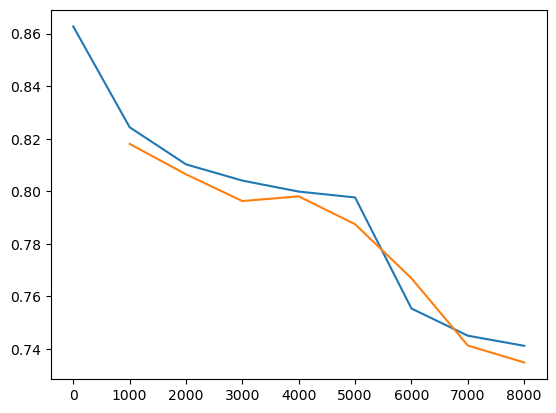

In [90]:
loss_train_bucket_means = []
for i in range(0, len(loss_train), log_every):
  loss_train_bucket_means.append(np.mean(loss_train[i:i+log_every]))

plt.plot([i*1000 for i in range(len(loss_train_bucket_means))], loss_train_bucket_means)
plt.plot([i*1000 for i in range(1, len(loss_val))], loss_val[1:])

plt.show()

# Save + Load Model

In [91]:
PATH = 'saved_models/20260329.pth'

In [92]:
# Manually save the current model

torch.save(model.state_dict(), PATH)

In [94]:
# Load a model (or checkpoint)

model = MovieRecommender(
    genres_len=len(genres),
    tags_len=len(final_movie_tags),
    top_movies_len=len(top_movies),
    all_years_len=len(year_to_num_movies),
    timestamp_num_bins=timestamp_num_bins,
    user_context_size=user_context_size,
    item_genre_embedding_size=item_genre_embedding_size,
    item_tag_embedding_size=item_tag_embedding_size,
    item_movieId_embedding_size=item_movieId_embedding_size,
    item_year_embedding_size=item_year_embedding_size,
    user_genre_embedding_size=user_genre_embedding_size,
    user_tag_embedding_size=user_tag_embedding_size,
    timestamp_feature_embedding_size=timestamp_feature_embedding_size,
)

# load from file path
model.load_state_dict(torch.load(PATH, weights_only=True))

model.eval()

MovieRecommender(
  (item_embedding_lookup): Embedding(3554, 40, padding_idx=3553)
  (item_embedding_tower): Sequential(
    (0): Linear(in_features=40, out_features=40, bias=True)
    (1): Tanh()
  )
  (item_genre_tower): Sequential(
    (0): Linear(in_features=20, out_features=10, bias=True)
    (1): Tanh()
  )
  (item_tag_tower): Sequential(
    (0): Linear(in_features=306, out_features=40, bias=True)
    (1): Tanh()
  )
  (year_embedding_lookup): Embedding(192, 10)
  (year_embedding_tower): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Tanh()
  )
  (user_genre_tower): Sequential(
    (0): Linear(in_features=40, out_features=30, bias=True)
    (1): Tanh()
  )
  (user_tag_tower): Sequential(
    (0): Linear(in_features=306, out_features=20, bias=True)
    (1): Tanh()
  )
  (timestamp_embedding_lookup): Embedding(1500, 10)
  (timestamp_embedding_tower): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Tanh()
  )
)

# Actually Using the Model

In [104]:
# for every movie, save all its embeddings
movieId_to_embedding = {}

ITEM_EMBEDDING_LOOKUP = model.item_embedding_lookup.weight
YEAR_EMBEDDING_LOOKUP = model.year_embedding_lookup.weight

for movieId in top_movies:
  movieId_to_embedding[movieId] = {}

  item_embedding = ITEM_EMBEDDING_LOOKUP[torch.tensor([item_emb_movieId_to_i[movieId]])]
  movieId_to_embedding[movieId]['MOVIEID_EMBEDDING'] = model.item_embedding_tower(item_embedding)

  year_embedding = YEAR_EMBEDDING_LOOKUP[torch.tensor([year_to_i[movieId_to_year[movieId]]])]
  movieId_to_embedding[movieId]['MOVIE_YEAR_EMBEDDING'] = model.year_embedding_tower(year_embedding)

  movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING'] = model.item_genre_tower(torch.tensor([movieId_to_genre_context[movieId]]))
  movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING'] = model.item_tag_tower(torch.tensor([movieId_to_tag_context[movieId]]))

  # compute the combined (concat) item/movie embedding
  item_id_emb = movieId_to_embedding[movieId]['MOVIEID_EMBEDDING']
  item_genre_emb = movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING']
  item_tag_emb = movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING']
  iteam_year_emb = movieId_to_embedding[movieId]['MOVIE_YEAR_EMBEDDING']
  movieId_to_embedding[movieId]['MOVIE_EMBEDDING_COMBINED'] = torch.cat((item_genre_emb, item_tag_emb, item_id_emb, iteam_year_emb), dim=1)

In [105]:
for emb_type in movieId_to_embedding[5952].keys():
  print(movieId_to_embedding[5952][emb_type].shape)

torch.Size([1, 40])
torch.Size([1, 10])
torch.Size([1, 10])
torch.Size([1, 40])
torch.Size([1, 100])


### Viewing Movies in 2D

In [ ]:
plt.figure(figsize=(15,15))
for movieId in top_movies[0:25]:
  i = item_emb_movieId_to_i[movieId]
  plt.scatter(ITEM_EMBEDDING_LOOKUP[i,0].data, ITEM_EMBEDDING_LOOKUP[i,1].data, s=200)
  plt.text(ITEM_EMBEDDING_LOOKUP[i,0].item(), ITEM_EMBEDDING_LOOKUP[i,1].item(), movieId_to_title[movieId][0:20], ha="center", va="center", color='black')
plt.grid('minor')

plt.show()

### Finding Most Similar Movies

In [106]:
# Compute pairwise cosine similarity between all movie combined embeddings.
#
# Previously used L2 (Euclidean) distance in a nested Python loop — O(N^2) iterations.
# This version stacks all embeddings into a matrix and does a single (N, D) x (D, N)
# matmul, which is orders of magnitude faster and uses cosine similarity instead.
#
# Cosine similarity is more appropriate here than L2 distance because the model was
# trained with a dot product objective: the embedding space is organized by angle,
# not magnitude. L2 conflates direction and scale; cosine only measures direction.
#
# Results are stored as (movieId, similarity) tuples sorted descending (most similar first).
# The movie itself is excluded from its own result list.

movie_ids = list(top_movies)

# Stack combined embeddings into a single matrix: (N, D)
emb_matrix = torch.stack([
    movieId_to_embedding[mid]['MOVIE_EMBEDDING_COMBINED'].view(-1)
    for mid in movie_ids
])

# L2-normalize each row so that matmul gives cosine similarity: (N, N)
emb_norm = torch.nn.functional.normalize(emb_matrix, dim=1)
sim_matrix = emb_norm @ emb_norm.T  # cosine similarity for all pairs

movieId_to_emb_type_to_similarities = {}
for i, movieId in enumerate(movie_ids):
    sims = sim_matrix[i]  # cosine similarity of movie i to all others
    # Sort descending; exclude self (j == i)
    sorted_indices = sims.argsort(descending=True)
    top = [
        (movie_ids[j.item()], sims[j].item())
        for j in sorted_indices
        if j.item() != i
    ][:100]
    movieId_to_emb_type_to_similarities[movieId] = {'MOVIE_EMBEDDING_COMBINED': top}


In [107]:
titles = [
    'Lord of the Rings: The Return of the King, The (2003)',
    'Star Wars: Episode IV - A New Hope (1977)',
    'Toy Story (1995)',
    'Saving Private Ryan (1998)',
    'Kill Bill: Vol. 1 (2003)',
    'American Pie (1999)',
    'Blair Witch Project, The (1999)',
    'Princess Mononoke (Mononoke-hime) (1997)'
]

emb_type = 'MOVIE_EMBEDDING_COMBINED'

table = '| Movie |'
for i in range(5):
  table += ' Similar {} |'.format(i+1)
table += '\n'
for i in range(5):
  table += '|-----'
table += '|\n'

# Print the top most similar movies
for title in titles:
  movieId = title_to_movieId[title]

  # Self is no longer included in the similarity list, so print the query title
  # directly and take the first 5 results (previously needed [0:5+1] to skip self)
  table += '| ' + title + ' | '
  for target_id, sim in movieId_to_emb_type_to_similarities[movieId][emb_type][0:5]:
    table += movieId_to_title[target_id] + ' | '
  table += '\n'

print(table)

| Movie | Similar 1 | Similar 2 | Similar 3 | Similar 4 | Similar 5 |
|-----|-----|-----|-----|-----|
| Lord of the Rings: The Return of the King, The (2003) | Harry Potter and the Deathly Hallows: Part 2 (2011) | Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986) | Stardust (2007) | Goonies, The (1985) | Harry Potter and the Deathly Hallows: Part 1 (2010) | 
| Star Wars: Episode IV - A New Hope (1977) | Star Wars: Episode VI - Return of the Jedi (1983) | Guardians of the Galaxy (2014) | Avengers: Infinity War - Part I (2018) | Star Trek (2009) | Rogue One: A Star Wars Story (2016) | 
| Toy Story (1995) | Toy Story 2 (1999) | Monsters, Inc. (2001) | Soul (2020) | Finding Nemo (2003) | Toy Story 3 (2010) | 
| Saving Private Ryan (1998) | Longest Day, The (1962) | Braveheart (1995) | Dirty Dozen, The (1967) | Apollo 13 (1995) | Inside Man (2006) | 
| Kill Bill: Vol. 1 (2003) | Blade Runner (1982) | French Connection, The (1971) | Planet of the Apes (1968) | Ex Machina (2015) | Dar

### Get Recommendations for Users

In [ ]:
for movieId in user_context_movies:
    print(movieId_to_title[movieId], movieId_to_genres[movieId])

In [100]:
user_type_to_favorite_genres = {
    'Fantasy Lover': ['Fantasy'],
    'Children\'s Movie Lover': ['Children'],
    'Horror Lover': ['Horror'],
    'Sci-Fi Lover': ['Sci-Fi'],
    'Comedy Lover': ['Comedy'],
    'Romance Lover': ['Romance'],
    'War Movie Lover': ['War'],

    # profile for myself
    'Myself': ['Fantasy', 'War', 'Horror', 'Drama', 'Action']
}

user_type_to_worst_genres = {
    'Fantasy Lover': ['Horror', 'Children'],
    'Children\'s Movie Lover': ['Horror', 'Romance', 'Drama'],
    'Horror Lover': ['Children'],
    'Sci-Fi Lover': ['Romance', 'Children'],
    'Comedy Lover': ['Children'],
    'Romance Lover': ['Children', 'Horror'],
    'War Movie Lover': ['Children'],

    # profile for myself
    'Myself': ['Romance']
}

user_type_to_favorite_movies = {
    'Fantasy Lover': [
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',
        'Willow (1988)',
        'Excalibur (1981)',
        'Conan the Barbarian (1982)',
        'Princess Bride, The (1987)',
        'Labyrinth (1986)',
        'Legend (1985)'
        ],
    'Children\'s Movie Lover': [
        'Toy Story 2 (1999)',
        'Finding Nemo (2003)',
        'Monsters, Inc. (2001)',
        'Toy Story (1995)',
        'Lion King, The (1994)',
        'Shrek (2001)'
        ],
    'Horror Lover': [
        'Blair Witch Project, The (1999)',
        'Silence of the Lambs, The (1991)',
        'Sixth Sense, The (1999)',
        'Shining, The (1980)',
        "Rosemary's Baby (1968)",
        'Halloween (1978)'
        ],
    'Sci-Fi Lover': [
        'Star Wars: Episode V - The Empire Strikes Back (1980)',
        'Matrix, The (1999)',
        'Terminator, The (1984)',
        'Alien (1979)',
        '2001: A Space Odyssey (1968)',
        'Blade Runner (1982)'
        ],
    'Comedy Lover': [
        'American Pie (1999)',
        'Dumb & Dumber (Dumb and Dumber) (1994)',
        'Austin Powers: The Spy Who Shagged Me (1999)',
        'Big Lebowski, The (1998)',
        'Monty Python and the Holy Grail (1975)',
        'Airplane! (1980)',
        'Spaceballs (1987)'
      ],
    'Romance Lover': [
        'Shakespeare in Love (1998)',
        'There\'s Something About Mary (1998)',
        'Sense and Sensibility (1995)',
        'When Harry Met Sally... (1989)',
        'Sleepless in Seattle (1993)',
        'Notting Hill (1999)'
    ],
    'War Movie Lover': [
        'Saving Private Ryan (1998)',
        'Apocalypse Now (1979)',
        'Full Metal Jacket (1987)',
        'Platoon (1986)',
        'Bridge on the River Kwai, The (1957)',
    ],

    # profile for myself
    'Myself': [
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',
        'Lord of the Rings: The Return of the King, The (2003)',
        '300 (2007)',
        'Saving Private Ryan (1998)',
        'Kill Bill: Vol. 1 (2003)',
        'Gladiator (2000)',
        'Braveheart (1995)'
    ]
}

value_for_favorite_genre_avg_rating = float(4.0)  # de-biased ratings max ~4.0 in training data
value_for_disliked_genre_avg_rating  = float(-2.0)

user_to_inference_context     = {}  # genre context vector (2*len(genres)-dim)
user_to_inference_history     = {}  # watch history: list of (emb_idx, movieId) tuples
user_to_inference_tag_context = {}  # tag profile: avg tag vector over seed movies

for user_type in user_type_to_favorite_genres.keys():
    inference_user_context = [0.0] * user_context_size

    # First half: avg rating per genre
    for genre in user_type_to_favorite_genres[user_type]:
        inference_user_context[user_context_genre_avg_rating_to_i[genre]] = value_for_favorite_genre_avg_rating
    for genre in user_type_to_worst_genres[user_type]:
        inference_user_context[user_context_genre_avg_rating_to_i[genre]] = value_for_disliked_genre_avg_rating

    # Second half: watch count fraction per genre (equal split among favorite genres)
    num_fav_genres = len(user_type_to_favorite_genres[user_type])
    for genre in user_type_to_favorite_genres[user_type]:
        inference_user_context[user_context_genre_watch_count_to_i[genre]] = float(1.0 / num_fav_genres)

    user_to_inference_context[user_type] = inference_user_context

    # Watch history: favorite movies go here instead of into the genre context vector
    # Only include movies that exist in the item embedding lookup
    history = [
        (item_emb_movieId_to_i[title_to_movieId[title]], title_to_movieId[title])
        for title in user_type_to_favorite_movies[user_type]
        if title_to_movieId[title] in item_emb_movieId_to_i
    ]
    user_to_inference_history[user_type] = history

    # Tag profile: average the tag vectors of seed movies
    tag_context = [0.0] * len(final_movie_tags)
    num_movies = 0
    for title in user_type_to_favorite_movies[user_type]:
        movieId = title_to_movieId[title]
        if movieId in movieId_to_tag_context:
            for j, val in enumerate(movieId_to_tag_context[movieId]):
                tag_context[j] += val
            num_movies += 1
    if num_movies > 0:
        tag_context = [v / num_movies for v in tag_context]
    user_to_inference_tag_context[user_type] = tag_context

In [101]:
model.eval()
user_to_top_recs = {}

for user_type in user_to_inference_context.keys():
    with torch.no_grad():
        # Genre context
        X_inference = torch.tensor([user_to_inference_context[user_type]])
        genre_embedding_inference = model.user_genre_tower(X_inference)

        # Tag profile
        X_tag_inference = torch.tensor([user_to_inference_tag_context[user_type]])
        tag_embedding_inference = model.user_tag_tower(X_tag_inference)

        # Watch history: avg pool of favorite movies' embeddings
        history = user_to_inference_history[user_type]
        if len(history) > 0:
            hist_ids     = torch.tensor([h[0] for h in history], dtype=torch.long).unsqueeze(0)  # (1, hist_len)
            hist_weights = torch.ones(1, len(history))                                             # (1, hist_len)
            hist_embs    = model.item_embedding_lookup(hist_ids)                                   # (1, hist_len, emb_dim)
            weight_sum   = hist_weights.unsqueeze(-1).abs().sum(dim=1).clamp(min=1e-6)
            history_emb  = (hist_embs * hist_weights.unsqueeze(-1)).sum(dim=1) / weight_sum        # (1, emb_dim)
        else:
            history_emb = torch.zeros(1, model.item_embedding_lookup.embedding_dim)

        # Timestamp: use most recent timestamp from training data
        timestamp_inference = torch.bucketize(torch.tensor([df_ratings['timestamp'].max()]), timestamp_bins, right=False)
        timestamp_embedding = model.timestamp_embedding_tower(model.timestamp_embedding_lookup(timestamp_inference))

        # Combine user side: history + genre + tag + timestamp
        user_and_timestamp_combined_embedding = torch.cat((history_emb, genre_embedding_inference, tag_embedding_inference, timestamp_embedding), dim=1)

        movieId_to_pred_score = {}
        for movieId in top_movies:
            item_embedding_combined_inference = movieId_to_embedding[movieId]['MOVIE_EMBEDDING_COMBINED']
            preds = torch.einsum('ij, ij -> i', user_and_timestamp_combined_embedding, item_embedding_combined_inference)
            movieId_to_pred_score[movieId] = preds

    top_recs = []
    show_top_recs = True
    for movieId, pred_score in list(sorted(movieId_to_pred_score.items(), key=lambda item: item[1], reverse=show_top_recs)):
        if len(top_recs) >= 10: break
        if movieId_to_title[movieId] not in user_type_to_favorite_movies[user_type]:
            top_recs.append(movieId)
    user_to_top_recs[user_type] = top_recs

In [102]:
for user_type in user_to_top_recs.keys():
  print("Hello, " + user_type)
  print("Because you like: [" + ','.join(user_type_to_favorite_genres[user_type]) + ']')
  print("And hate: [" + ','.join(user_type_to_worst_genres[user_type]) + ']')
  print("And enjoyed these movies:")
  for title in user_type_to_favorite_movies[user_type]:
    print(title)
  print()

  print("You should watch:")
  for movieId in user_to_top_recs[user_type]:
    print(movieId_to_title[movieId])
  print()

Hello, Fantasy Lover
Because you like: [Fantasy]
And hate: [Horror,Children]
And enjoyed these movies:
Lord of the Rings: The Fellowship of the Ring, The (2001)
Willow (1988)
Excalibur (1981)
Conan the Barbarian (1982)
Princess Bride, The (1987)
Labyrinth (1986)
Legend (1985)

You should watch:
Cool Hand Luke (1967)
Touch of Evil (1958)
Treasure of the Sierra Madre, The (1948)
Kid, The (1921)
Gold Rush, The (1925)
Once Upon a Time in the West (C'era una volta il West) (1968)
Yojimbo (1961)
Adventures of Robin Hood, The (1938)
Battleship Potemkin (1925)
Spring, Summer, Fall, Winter... and Spring (Bom yeoreum gaeul gyeoul geurigo bom) (2003)

Hello, Children's Movie Lover
Because you like: [Children]
And hate: [Horror,Romance,Drama]
And enjoyed these movies:
Toy Story 2 (1999)

You should watch:
Highlander: Endgame (Highlander IV) (2000)
Teenage Mutant Ninja Turtles III (1993)
RoboCop 3 (1993)
You, Me and Dupree (2006)
City Slickers II: The Legend of Curly's Gold (1994)
Soapdish (1991)
H

In [ ]:
# sanity check - make sure we aren't just recommending the higest rated movies
# NOTE: this is an extremely common problem in rec systems as the model learns
# to play it safe and just recommend what almost is highly rated.
for movieId, avg_rating in sorted(movieId_to_avg_rating.items(), key=lambda item: item[1], reverse=True)[0:10]:
  print(movieId_to_title[movieId], avg_rating)

In [ ]:
# Finding the 'most representative' movies for a specfic GENRE
genre = 'Horror'
genre_context = [0.0] * len(genres)
genre_context[genre_to_i[genre]] = float(1.0)
genre_context_emb = model.item_genre_tower(torch.tensor([genre_context]))

movieId_to_dist = {}
for movieId in top_movies:
  distance = torch.sqrt(torch.sum(torch.pow(torch.subtract(movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING'].view(-1), genre_context_emb.view(-1)), 2), dim=0))
  movieId_to_dist[movieId] = distance.item()

for movieId,dist in list(sorted(movieId_to_dist.items(), key=lambda item: item[1]))[0:10]:
    print(movieId_to_title[movieId])

In [ ]:
# Finding the 'most representative' movies for a specfic TAG
tags = ['horror', 'gore', 'torture']
# tags = ['dystopia', 'artificial intelligence', 'martial arts']
tag_context = [0.0] * len(final_movie_tags)
for tag in tags:
  tag_context[tag_to_i[tag]] = float(10.0)
tag_context_emb = model.item_tag_tower(torch.tensor([tag_context]))

movieId_to_dist = {}
for movieId in top_movies:
  distance = torch.sqrt(torch.sum(torch.pow(torch.subtract(movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING'].view(-1), tag_context_emb.view(-1)), 2), dim=0))
  movieId_to_dist[movieId] = distance.item()

for movieId,dist in list(sorted(movieId_to_dist.items(), key=lambda item: item[1]))[0:10]:
    print(movieId_to_title[movieId])